In [ ]:
import pandas as pd

df = pd.read_csv("data/full_data.csv")
df = df[["text", "emotion"]]  
df.head()


,text,emotion
0,Goed om te weten 😊,['approval']
1,Toen realiseerden we ons dat hetero's zich kle...,['realization']
2,Ik was de site aan het bekijken en dacht dat r...,['disapproval']
3,Dank je voor dit. Het vat precies samen wat ik...,['gratitude']
4,Ik geniet echt van seizoen 3 maar dit zou het ...,['joy']


In [8]:
from sklearn.preprocessing import LabelEncoder

# 👀 Zorg dat dit je échte emotie-kolom is
df["emotion"] = df["emotion"].astype(str)  # of df["label_names"]

le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion"])

print("Aantal unieke labels:", df["label"].nunique())
print(df["emotion"].value_counts().head(20))



Aantal unieke labels: 784
emotion
['neutral']           16021
['admiration']         3384
hateful                2640
['gratitude']          2378
['approval']           2367
['amusement']          2046
['disapproval']        1809
['annoyance']          1809
['love']               1760
['curiosity']          1729
['anger']              1265
non-hateful            1125
['optimism']           1087
['confusion']          1057
['joy']                1052
['sadness']            1003
['surprise']            902
['disappointment']      888
['caring']              831
['realization']         749
Name: count, dtype: int64


In [9]:
# aantal voorbeelden per label
counts = df["label"].value_counts()

# kies een drempel
MIN_SAMPLES = 2  # of 5 als je streng wilt zijn

valid_labels = counts[counts >= MIN_SAMPLES].index
df_filtered = df[df["label"].isin(valid_labels)].copy()

print("Origineel aantal rows:", len(df))
print("Na filteren:", len(df_filtered))
print("Aantal labels:", df_filtered["label"].nunique())

Origineel aantal rows: 58028
Na filteren: 57686
Aantal labels: 442


In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_filtered,
    test_size=0.15,
    random_state=3,
    stratify=df_filtered["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=3,
    stratify=train_df["label"]
)


In [16]:
from transformers import AutoTokenizer

model_name = "GroNLP/bert-base-dutch-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


In [17]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["text", "emotion"])
val_ds   = val_ds.remove_columns(["text", "emotion"])
test_ds  = test_ds.remove_columns(["text", "emotion"])

train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")


Map: 100%|██████████| 8653/8653 [00:00<00:00, 9099.27 examples/s] 


In [18]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="results",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,          # goed beginpunt
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
)


In [20]:
import transformers
transformers.__version__


'4.57.3'

In [25]:
import evaluate
import numpy as np

metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    accuracy = (preds == labels).mean()
    
    f1_macro = metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    
    return {"accuracy": accuracy, "f1_macro": f1_macro}


In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


/var/folders/6q/myq0l3dj2y15rk03py2ml2180000gn/T/ipykernel_23866/2110798571.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
2605,2.692800
5210,2.019000
7815,1.739900
10420,1.552400


TrainOutput(global_step=10420, training_loss=2.001022649314719, metrics={'train_runtime': 22869.0425, 'train_samples_per_second': 7.29, 'train_steps_per_second': 0.456, 'total_flos': 1.1042937326174208e+16, 'train_loss': 2.001022649314719, 'epoch': 4.0})

In [27]:
trainer.evaluate(test_ds)


{'eval_loss': 2.189401626586914,
 'eval_accuracy': 0.5123078701028545,
 'eval_f1_macro': 0.045423514064507876,
 'eval_runtime': 180.0378,
 'eval_samples_per_second': 48.062,
 'eval_steps_per_second': 3.005,
 'epoch': 4.0}

In [29]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    n_trials=10
)


/var/folders/6q/myq0l3dj2y15rk03py2ml2180000gn/T/ipykernel_23866/550307035.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-12-17 20:01:54,913] A new study created in memory with name: no-name-51396ba9-5708-447a-8f50-b0a6325cf40a
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a dow

RuntimeError: MPS backend out of memory (MPS allocated: 5.37 GB, other allocations: 1.40 GB, max allowed: 6.77 GB). Tried to allocate 12.00 MB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

Step,Training Loss


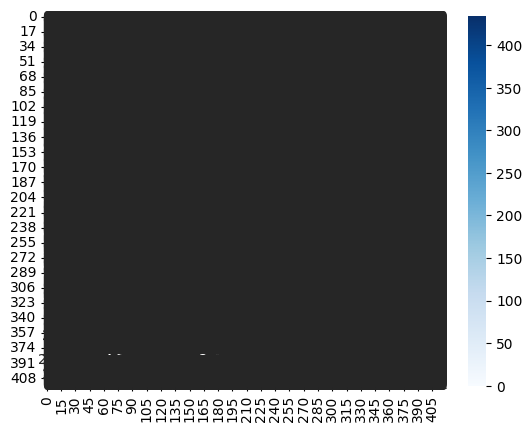

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = trainer.predict(test_ds).predictions.argmax(axis=1)
cm = confusion_matrix(test_df["label"], preds)

sns.heatmap(cm, annot=True, cmap="Blues")
plt.show()
